# Лабораторная № 4. Кластеризация

### Подготовка датасета

In [1]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [2]:
# Загрузка данных из Excel файла
df = pd.read_excel('Real estate valuation data set.xlsx')


In [3]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Возраст дома,Кол-во магазинов,Расстояние до ближайшей станции метро
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9,старый,много,среднее
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2,старый,много,среднее
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3,средний возраст,среднее,среднее
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8,средний возраст,среднее,среднее
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1,средний возраст,среднее,среднее


In [4]:
df.columns.tolist()

['No',
 'X1 transaction date',
 'X2 house age',
 'X3 distance to the nearest MRT station',
 'X4 number of convenience stores',
 'X5 latitude',
 'X6 longitude',
 'Y house price of unit area',
 'Возраст дома',
 'Кол-во магазинов',
 'Расстояние до ближайшей станции метро']

In [5]:
vals = df["Возраст дома"].unique()
vals

array(['старый', 'средний возраст', 'новостройка'], dtype=object)

In [6]:
# сохраняем только числовые столбцы. Категориальные кодируем в числовые. Целевую переменную (если она есть) - убираем
cols_for_clusters = ['X1 transaction date','X2 house age',
 'X3 distance to the nearest MRT station',
 'X4 number of convenience stores',
 'X5 latitude',
 'X6 longitude',]

df_1= df[cols_for_clusters].copy() # делаем копию, чтобы не было сюрпризов с исходным набором данных

In [7]:
df_1.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.916667,32.0,84.87882,10,24.98298,121.54024
1,2012.916667,19.5,306.59470,9,24.98034,121.53951
2,2013.583333,13.3,561.98450,5,24.98746,121.54391
3,2013.500000,13.3,561.98450,5,24.98746,121.54391
4,2012.833333,5.0,390.56840,5,24.97937,121.54245


In [8]:
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Возраст дома,Кол-во магазинов,Расстояние до ближайшей станции метро
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9,старый,много,среднее
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2,старый,много,среднее
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3,средний возраст,среднее,среднее
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8,средний возраст,среднее,среднее
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1,средний возраст,среднее,среднее
...,...,...,...,...,...,...,...,...,...,...,...
409,410,2013.000000,13.7,4082.01500,0,24.94155,121.50381,15.4,средний возраст,мало,далеко
410,411,2012.666667,5.6,90.45606,9,24.97433,121.54310,50.0,средний возраст,много,среднее
411,412,2013.250000,18.8,390.96960,7,24.97923,121.53986,40.6,старый,много,среднее
412,413,2013.000000,8.1,104.81010,5,24.96674,121.54067,52.5,средний возраст,среднее,среднее


In [9]:
X = df_1
y = df["Возраст дома"].replace(vals, [0, 1, 2])
yvals = df["Возраст дома"]

/tmp/ipykernel_13394/382835519.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df["Возраст дома"].replace(vals, [0, 1, 2])


### Распространенные алгоритмы кластеризации

In [10]:
import mpl_toolkits.mplot3d  # noqa: F401
from sklearn.cluster import KMeans

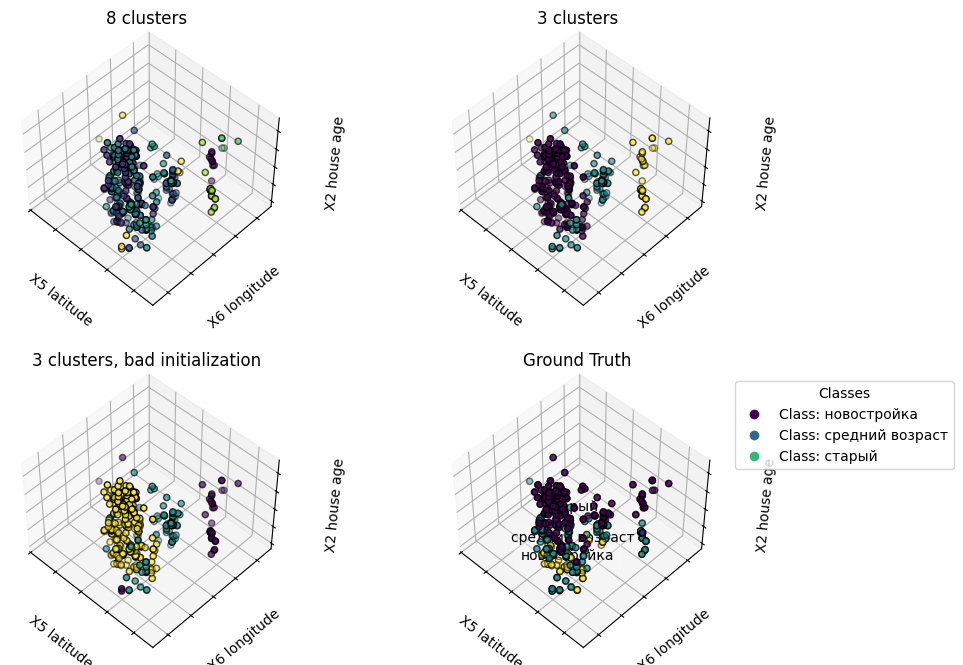

In [11]:
#cols_for_clusters = ['X1 transaction date','X2 house age','X3 distance to the nearest MRT station','X4 number of convenience stores',
# 'X5 latitude',
# 'X6 longitude',]

estimators = [
    ("k_means_iris_8", KMeans(n_clusters=8)),
    ("k_means_iris_3", KMeans(n_clusters=3)),
    ("k_means_iris_bad_init", KMeans(n_clusters=3, n_init=1, init="random")),
]

fig = plt.figure(figsize=(10, 8))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]
for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X)
    labels = est.labels_

    ax.scatter(X["X5 latitude"], X["X6 longitude"], X["X2 house age"], c=labels.astype(float), edgecolor="k")

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("X5 latitude")
    ax.set_ylabel("X6 longitude")
    ax.set_zlabel("X2 house age")
    ax.set_title(title)

# Plot the ground truth
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

for name, label in [(vals[0], 0), (vals[1], 1), (vals[2], 2)]:
    ds = df[df["Возраст дома"]==name]
    ax.text3D(
        ds["X5 latitude"].mean(),
        ds["X6 longitude"].mean(),
        ds["X2 house age"].mean(),
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )
unique_classes = sorted(list(set(vals))) # Используем vals как примеры классов
scatter_gt = ax.scatter(
    X["X5 latitude"],
    X["X6 longitude"],
    X["X2 house age"],
    c=y,
    edgecolor="k",
    label="Data Points" # Общая метка
)

# Создаем_handles_ для легенды вручную
legend_handles = []
legend_labels = []
for i, cls_name in enumerate(unique_classes):
    # Создаем точку того же цвета, что и класс в colormap
    # Примечание: цвет берется из нормализации scatter_gt, если y содержит индексы
    # Если y содержит строки или специфические значения, логика может потребовать корректировки cmap
    handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter_gt.cmap(i / len(unique_classes)), markersize=8, label=f"Class: {cls_name}")
    legend_handles.append(handle)
    legend_labels.append(f"Class: {cls_name}")

ax.scatter(X["X5 latitude"], X["X6 longitude"], X["X2 house age"], c=y, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("X5 latitude")
ax.set_ylabel("X6 longitude")
ax.set_zlabel("X2 house age")
ax.set_title("Ground Truth")

plt.subplots_adjust(wspace=0.25, hspace=0.25)
ax.legend(handles=legend_handles, title="Classes", loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()


In [12]:

from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score


n_clusters = np.arange(2, 21)

In [13]:
best_metric = [0, 10000, 0,[]]

silhouette_score_values = []
adjusted_rand_score_values = []


for n in n_clusters:

    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10)
    clusterer.fit(X)
    y_pred = clusterer.predict(X)

    score1 = metrics.silhouette_score(X, y_pred)
    silhouette_score_values.append(score1)

    score2 = metrics.adjusted_rand_score(y, y_pred)
    adjusted_rand_score_values.append(score2)


    if score1 < best_metric[1] and score2 > best_metric[2]:
          best_metric[1] = score1
          best_metric[2] = score2
          best_metric[3] = clusterer.cluster_centers_
          best_metric[0] = n

In [14]:
best_metric

[np.int64(7),
 np.float64(0.5816492170084387),
 0.011310796140356053,
 array([[2.01312099e+03, 1.53207407e+01, 2.04428487e+02, 5.97037037e+00,
         2.49728373e+01, 1.21540173e+02],
        [2.01317473e+03, 1.90129032e+01, 4.19309281e+03, 1.29032258e-01,
         2.49461042e+01, 1.21502082e+02],
        [2.01318537e+03, 1.35612245e+01, 2.05165453e+03, 2.55102041e+00,
         2.49636939e+01, 1.21519179e+02],
        [2.01316981e+03, 1.76226415e+01, 1.27725070e+03, 1.62264151e+00,
         2.49672168e+01, 1.21535402e+02],
        [2.01326667e+03, 2.59000000e+01, 6.04290660e+03, 1.00000000e+00,
         2.49520540e+01, 1.21479336e+02],
        [2.01315226e+03, 2.11090226e+01, 5.17015890e+02, 4.98496241e+00,
         2.49740979e+01, 1.21540231e+02],
        [2.01303125e+03, 1.74750000e+01, 2.99274338e+03, 7.50000000e-01,
         2.49646750e+01, 1.21532511e+02]])]

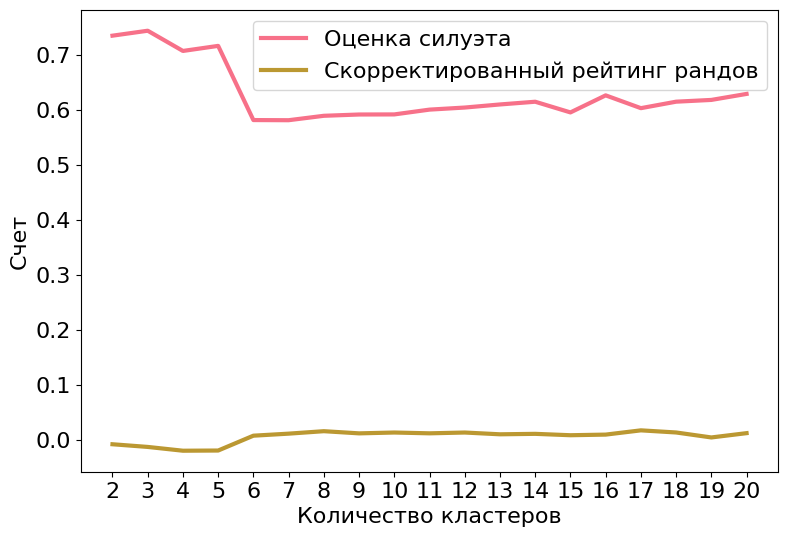

In [15]:
plt.figure(figsize=(9, 6))
plt.plot(n_clusters, silhouette_score_values, linewidth=3, label='Оценка силуэта') #Silhouette score
plt.plot(n_clusters, adjusted_rand_score_values, linewidth=3, label='Скорректированный рейтинг рандов') #Adjusted rand score
plt.xlabel('Количество кластеров', size=16) #Number of clusters
plt.ylabel('Счет', size=16) #Score
plt.xticks(n_clusters, size=16)
plt.yticks(size=16)
plt.legend(loc='best', fontsize=16)

plt.show()


#plt.figure(figsize=(9, 6))
#plt.plot(n_clusters, within_cluster_dist_values, linewidth=3, label='Within-cluster distance')
#plt.xlabel('Number of clusters', size=16)
#plt.ylabel('Score', size=16)
#plt.xticks(n_clusters, size=16)
#plt.yticks(size=16)
#plt.legend(loc='best', fontsize=16)

#plt.show()

### Иерархическая кластеризация

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [17]:
# добавить Ordinal


In [18]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
df[['Возраст дома', 'Кол-во магазинов', 'Расстояние до ближайшей станции метро']] = enc.fit_transform(df[['Возраст дома', 'Кол-во магазинов', 'Расстояние до ближайшей станции метро']])
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Возраст дома,Кол-во магазинов,Расстояние до ближайшей станции метро
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9,2.0,1.0,2.0
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2,2.0,1.0,2.0
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3,1.0,2.0,2.0
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8,1.0,2.0,2.0
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1,1.0,2.0,2.0


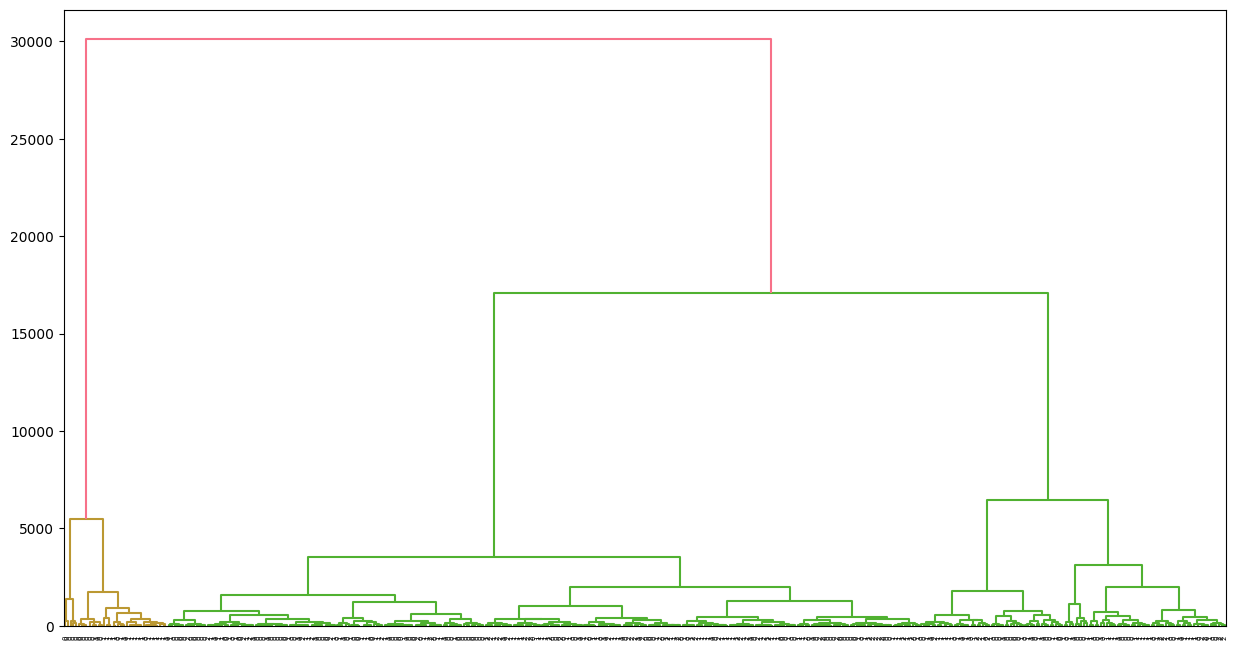

In [19]:
samples = df.values

# Реализация иерархической кластеризации при помощи функции linkage
mergings = linkage(samples, method='ward')
# попробуйте с другими методами
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html

plt.figure(figsize=(15, 8))
# Строим дендрограмму, указав параметры удобные для отображения
dendrogram(mergings,
           labels=list(y),
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()

### DBSCAN

In [20]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

In [21]:
mins = X.shape[1]

['y', 'b', 'g', 'r']


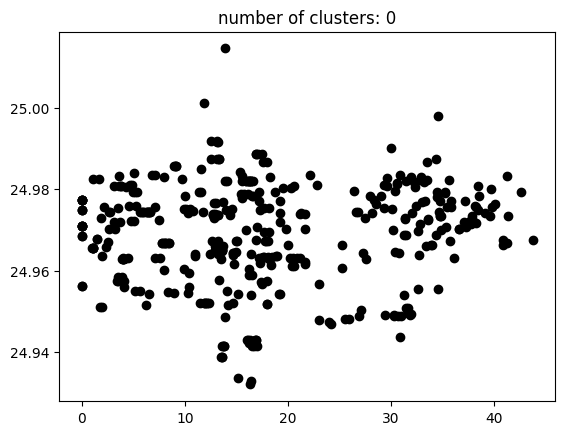

In [22]:
db = DBSCAN(eps=0.5, min_samples=12).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Plot result

# Black removed and is used for noise instead.
unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
	if k == -1:
		# Black used for noise.
		col = 'k'

	class_member_mask = (labels == k)

	xy = X[class_member_mask & core_samples_mask]
	plt.plot(xy["X2 house age"], xy["X5 latitude"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

	xy = X[class_member_mask & ~core_samples_mask]
	plt.plot(xy["X2 house age"], xy["X5 latitude"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()

# X["X5 latitude"],
 #   X["X6 longitude"],
  #  X["X2 house age"],
    #ds["petal-lenght"].mean(),
 #       ds["sepal-width"].mean(),
  #      ds["sepal-lenght"].mean(),

/tmp/ipykernel_13394/1178726990.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


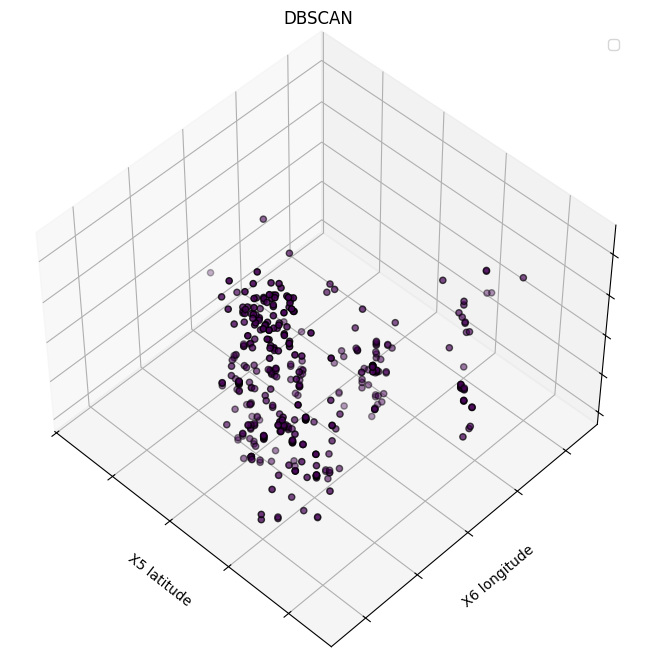

In [23]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

ax.scatter(X["X5 latitude"], X["X6 longitude"], X["X2 house age"], c=labels.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("X5 latitude")
ax.set_ylabel("X6 longitude")
ax.set_zlabel("X2 house age")
ax.set_title("DBSCAN")
ax.legend()
plt.show()

In [25]:
# evaluation metrics
print(X)
print(labels)
print(f"Number of unique labels: {len(np.unique(labels))}")

# Проверяем, что есть минимум 2 кластера для silhouette_score
if len(np.unique(labels)) >= 2:
    sc = metrics.silhouette_score(X, labels)
    print("Silhouette Coefficient:%0.2f" % sc)
else:
    print("Silhouette Coefficient: N/A (требуется минимум 2 кластера)")

# Adjusted Rand Index требует минимум 2 кластера в обоих наборах меток
if len(np.unique(labels)) >= 2 and len(np.unique(y)) >= 2:
    ari = adjusted_rand_score(y, labels)
    print("Adjusted Rand Index: %0.2f" % ari)
else:
    print("Adjusted Rand Index: N/A (требуется минимум 2 кластера в обоих наборах)")

     X1 transaction date  X2 house age  \
0            2012.916667          32.0   
1            2012.916667          19.5   
2            2013.583333          13.3   
3            2013.500000          13.3   
4            2012.833333           5.0   
..                   ...           ...   
409          2013.000000          13.7   
410          2012.666667           5.6   
411          2013.250000          18.8   
412          2013.000000           8.1   
413          2013.500000           6.5   

     X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                  84.87882                               10   
1                                 306.59470                                9   
2                                 561.98450                                5   
3                                 561.98450                                5   
4                                 390.56840                                5   
..             